# Importación de librerías:
## pandas: importación y manipulacióde datos
## numpy: calculos numericos y operacion con arrays multidimensionales
## matplotlib.pyplot: visualización de gráficos
## seaborn: visualización estadística avanzada basada en matplotlib
## torch: creación y entrenamiento de redes neuronales
## train_test_split: divide los datos en entrenamiento y validación
## labelEncoder: codificación de etiquetas categóricas a numéricas
## classification_report: reporte detallado de métricas
## accuracy_score, f1_score, precision_score, recall_score, confusion_matrix: metricas 
## RobertaTokenizerFast: tokenizacion de texto para el modelo RoBERTa
## RobertaForSequenceClassification: modelo RoBERTa preentrenado adaptado para clasificación.
## rrainer: entrenamiento y evaluación de modelos de Hugging Face
## trainingArguments: Configuración de hiperparámetros para el entrenamiento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import RobertaTokenizerFast

In [2]:
data = pd.read_csv("reviews_22052025_2400.csv")

In [3]:
data.rename(columns={'classification': 'Cluster'}, inplace=True)

# Se convierte Genuine en 1 y Fake en 0

In [4]:
data['Cluster'] = data['Cluster'].replace({'Genuine': 1, 'Fake': 0}).astype(int)
print(data['Cluster'].unique())

[1 0]


# Se crea un dataset solo con las columnas text y Cluster

In [5]:
columnas = ['text', 'Cluster']
df = data[columnas].copy()

In [6]:
print("--- Verificando DataFrame 'df' antes del finetuning ---")
print("Shape del df:", df.shape)
print("Columnas del df:", df.columns.tolist())
print("Primeras filas del df:\n", df.head())
print("-" * 30)

# Verificación de columnas necesarias
if 'Cluster' not in df.columns:
    raise ValueError("El DataFrame 'df' (después de la transformación) debe contener una columna llamada 'Cluster'.")
if 'text' not in df.columns:
     raise ValueError("El DataFrame 'df' (después de la transformación) debe contener una columna llamada 'text'.")


--- Verificando DataFrame 'df' antes del finetuning ---
Shape del df: (1850, 2)
Columnas del df: ['text', 'Cluster']
Primeras filas del df:
                                                 text  Cluster
0  I needed an honest mechanic with good communic...        1
1  It's Arby's and it's finally open!  They've on...        1
2  The Westshore Grand, A Tribute Portfolio Hotel...        0
3  The worst pedi ever! \nWorst mani ever \nI nee...        1
4  Food was outstanding and the employees are so ...        0
------------------------------


# Conversion de etiquetas a número
## se transforma los valores de Cluster a valores númericos

In [7]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Cluster'])

In [8]:
num_labels = len(label_encoder.classes_)
class_names = [str(c) for c in label_encoder.classes_]  # Aseguramos que las clases sean cadenas
print(f"\nNúmero de clases (clusters) encontradas: {num_labels}")
print(f"Clases originales y su mapeo a enteros: {list(zip(class_names, range(num_labels)))}")


Número de clases (clusters) encontradas: 2
Clases originales y su mapeo a enteros: [('0', 0), ('1', 1)]


In [9]:
min_test_size_required = num_labels
test_size_val = max(min_test_size_required, int(len(df) * 0.2))

if len(df) - test_size_val < num_labels:
    raise ValueError(f"Dataset demasiado pequeño ({len(df)} filas) para una división estratificada con {num_labels} clases. "
                     f"El set de entrenamiento ({len(df) - test_size_val}) debe tener al menos {num_labels} muestras.")

print(f"Usando tamaño de validación (filas): {test_size_val}")

Usando tamaño de validación (filas): 370


# Division de datos en entrenamiento y validación

In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=test_size_val,
    random_state=42,
    stratify=df['label']
)

print(f"Tamaño del conjunto de entrenamiento: {len(train_df)}")
print(f"Tamaño del conjunto de validación: {len(val_df)}")

Tamaño del conjunto de entrenamiento: 1480
Tamaño del conjunto de validación: 370


# Se carga el tokenzaro de roberta-base

In [11]:
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
max_length = 350

# Se crea un dataset compatible con PyTorch

In [12]:
class TextClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [13]:
train_dataset = TextClassificationDataset(train_df['text'], train_df['label'], tokenizer, max_length)
val_dataset = TextClassificationDataset(val_df['text'], val_df['label'], tokenizer, max_length)

# Se carga el modelo RoBERTa 

In [14]:
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=num_labels)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
output_dir = "./roberta_finetuned_clusters"

# Se define los parametros del entrenamiento

In [16]:
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    report_to="none"
)

In [17]:
output_dir = "./roberta_finetuned_clusters"

# Se definen las metricas

In [18]:
def compute_metrics(p):
    pred = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    f1 = f1_score(labels, pred, average='weighted')
    acc = accuracy_score(labels, pred)
    return {"accuracy": acc, "f1": f1}

# Se entrena el modelo

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\omen\AppData\Local\Temp\ipykernel_2372\2721217396.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [20]:
print("\nIniciando entrenamiento...")
trainer.train()
print("Entrenamiento finalizado.")
print("\nEvaluando el modelo en el conjunto de validación final y generando reportes...")


Iniciando entrenamiento...


Step,Training Loss
10,0.711800
20,0.703400
30,0.682200
40,0.708200
50,0.705400
60,0.685900
70,0.700700
80,0.686300
90,0.676800
100,0.696800


Entrenamiento finalizado.

Evaluando el modelo en el conjunto de validación final y generando reportes...


# Evaluacion del modelo

In [21]:
predictions = trainer.predict(val_dataset)

# Obtención de las etiquetas 

In [22]:
true_labels_indices = predictions.label_ids
predicted_labels_indices = np.argmax(predictions.predictions, axis=1)

# Impresión de metricas


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       196
           1       0.66      0.76      0.70       174

    accuracy                           0.70       370
   macro avg       0.70      0.70      0.70       370
weighted avg       0.71      0.70      0.70       370


Calculando la Matriz de Confusión...

Matriz de Confusión (Filas = Verdadero, Columnas = Predicho):

     0    1
0  127   69
1   42  132


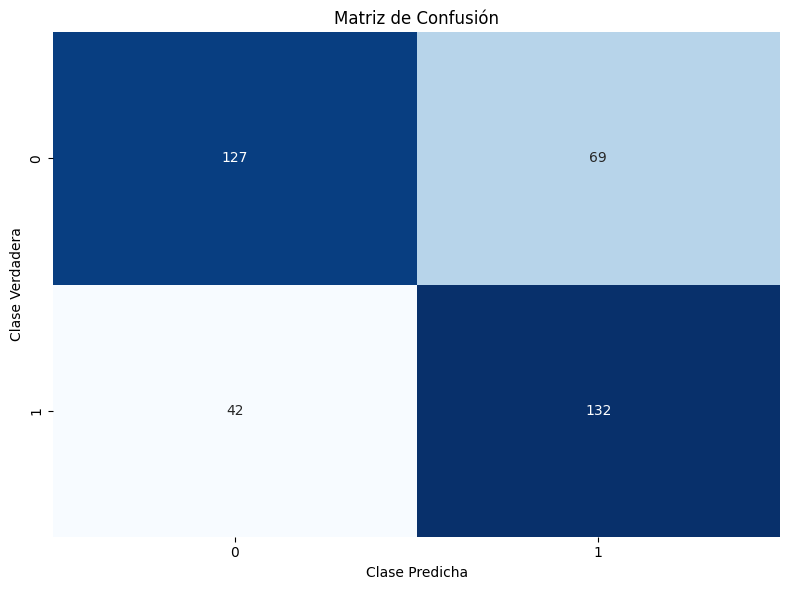


Ejemplo de predicciones vs etiquetas verdaderas:


In [23]:
print("\nReporte de Clasificación:")
report = classification_report(true_labels_indices, predicted_labels_indices, target_names=class_names)
print(report)
print("\nCalculando la Matriz de Confusión...")
cm = confusion_matrix(true_labels_indices, predicted_labels_indices)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nMatriz de Confusión (Filas = Verdadero, Columnas = Predicho):\n")
print(cm_df)
if num_labels > 1:
    plt.figure(figsize=(max(8, num_labels), max(6, num_labels * 0.8)))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Matriz de Confusión')
    plt.ylabel('Clase Verdadera')
    plt.xlabel('Clase Predicha')
    plt.tight_layout()
    plt.show()
print("\nEjemplo de predicciones vs etiquetas verdaderas:")
predicted_clusters = label_encoder.inverse_transform(predicted_labels_indices)
true_clusters = label_encoder.inverse_transform(true_labels_indices)

val_texts = val_df['text'].reset_index(drop=True)
val_true_labels = val_df['Cluster'].reset_index(drop=True)


In [24]:
print("\nEjemplo de predicciones vs etiquetas verdaderas:")
predicted_clusters = label_encoder.inverse_transform(predicted_labels_indices)
true_clusters = label_encoder.inverse_transform(true_labels_indices)

val_texts = val_df['text'].reset_index(drop=True)
val_true_labels = val_df['Cluster'].reset_index(drop=True)
# Mostramos algunos ejemplos
for i in range(min(5, len(val_texts))): # Muestra hasta 5 ejemplos
    print(f"Texto: {val_texts[i][:100]}...") # Muestra los primeros 100 caracteres
    print(f"  Etiqueta Verdadera (Cluster): {val_true_labels[i]}")
    print(f"  Predicción (Cluster): {predicted_clusters[i]}")
    print("-" * 30)

# --- INICIO: Grabar el modelo y artefactos necesarios ---
import pickle
import os
import json # Para guardar la configuración

print(f"\nGuardando el modelo, tokenizador y artefactos adicionales en {output_dir}...")

# 1. Guardar el modelo y el tokenizador
# trainer.save_model() guarda el modelo y también el tokenizador si se pasó al Trainer.
# También puedes hacerlo explícitamente:
# model.save_pretrained(output_dir)
# tokenizer.save_pretrained(output_dir)
# Pero trainer.save_model() es más conciso aquí.
trainer.save_model(output_dir)
print(f"Modelo y tokenizador guardados en: {output_dir}")

# 2. Guardar el LabelEncoder
label_encoder_path = os.path.join(output_dir, "label_encoder.pkl")
with open(label_encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"LabelEncoder guardado en: {label_encoder_path}")

# 3. Guardar información adicional útil para la inferencia
inference_config = {
    "max_length": max_length,
    "class_names": class_names, # Contiene los nombres originales de los clusters
    "num_labels": num_labels   # Aunque esto está en la config del modelo, es bueno tenerlo explícito
}
inference_config_path = os.path.join(output_dir, "inference_config.json")
with open(inference_config_path, 'w') as f:
    json.dump(inference_config, f, indent=4)
print(f"Configuración de inferencia guardada en: {inference_config_path}")

print("\nProceso de guardado completado.")
print(f"Los artefactos del modelo están listos en el directorio: '{os.path.abspath(output_dir)}'")
print("Para cargar el modelo en otro script:")
print("  from transformers import RobertaForSequenceClassification, RobertaTokenizerFast")
print("  import pickle")
print("  import json")
print(f"  model_path = '{os.path.abspath(output_dir)}'")
print("  loaded_model = RobertaForSequenceClassification.from_pretrained(model_path)")
print("  loaded_tokenizer = RobertaTokenizerFast.from_pretrained(model_path)")
print("  with open(os.path.join(model_path, 'label_encoder.pkl'), 'rb') as f:")
print("      loaded_label_encoder = pickle.load(f)")
print("  with open(os.path.join(model_path, 'inference_config.json'), 'r') as f:")
print("      loaded_inference_config = json.load(f)")
print("  # loaded_max_length = loaded_inference_config['max_length']")
print("  # loaded_class_names = loaded_inference_config['class_names']")
# --- FIN: Grabar el modelo y artefactos necesarios ---


Ejemplo de predicciones vs etiquetas verdaderas:
Texto: Shrimp pasta was delicious.. delivery was hot and prompt. Chicken tenders were worth it. We will ord...
  Etiqueta Verdadera (Cluster): 1
  Predicción (Cluster): 1
------------------------------
Texto: Luv it! The staff are friendly & accommodating. Our studio King was just divine. Simply relaxing and...
  Etiqueta Verdadera (Cluster): 0
  Predicción (Cluster): 1
------------------------------
Texto: Cafe Mochi No Happy Hour on a Friday!! 
 Recommendation: Have it on Friday!
My wife said she wants h...
  Etiqueta Verdadera (Cluster): 0
  Predicción (Cluster): 0
------------------------------
Texto: This place is by far the best sushi place in SB! The press boxes are all amazing. The Montecito and ...
  Etiqueta Verdadera (Cluster): 0
  Predicción (Cluster): 0
------------------------------
Texto: This is a great place! The manager Bart is always there and keeps the gym very clean and the machine...
  Etiqueta Verdadera (Cluster):

In [25]:
df = pd.read_csv("reviews_22052025_2400.csv")

data.rename(columns={'classification': 'Cluster'}, inplace=True)
data['Cluster'] = data['Cluster'].replace({'Genuine': 1, 'Fake': 0}).astype(int)
print(data['Cluster'].unique())
columnas = ['text', 'Cluster']
df = data[columnas].copy()





[1 0]


In [26]:
df.columns

Index(['text', 'Cluster'], dtype='object')

Loading model and artifacts from: ./roberta_finetuned_clusters
LabelEncoder loaded. Original classes: [0 1]
Max length: 350
Number of labels: 2
Class names for reporting (from loaded LabelEncoder): ['0', '1']
Using device: cuda

Loading new dataset from: reviews_22052025_100.csv
New dataset loaded. Number of samples: 100
Unique true labels in new data (numeric): [0 1]

Making predictions on the new dataset...
Predictions completed.

Evaluating model on the new dataset...

Classification Report on New Data:
              precision    recall  f1-score   support

           0     0.7308    0.7308    0.7308        52
           1     0.7083    0.7083    0.7083        48

    accuracy                         0.7200       100
   macro avg     0.7196    0.7196    0.7196       100
weighted avg     0.7200    0.7200    0.7200       100

Accuracy on New Data: 0.7200
Weighted F1-Score on New Data: 0.7200

Calculating Confusion Matrix for New Data...

Confusion Matrix (Rows = True, Columns = Predic

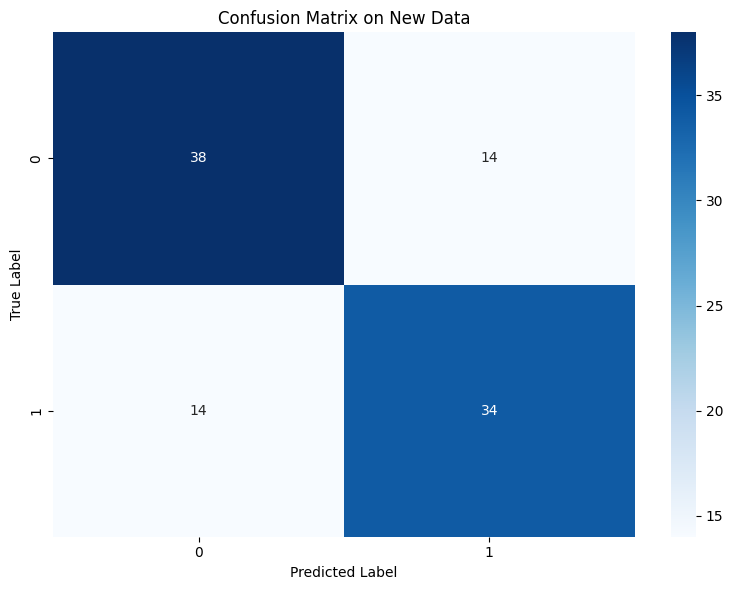


Example predictions vs true labels from new data:
Text: Excellent customer service! I use this cleaners weekly, and I'm very happy. They take the upmost care with my garments they treat me like a king. I'm ...
  True Label (Original): 0
  True Label (Numeric): 0
  Predicted Label (Name): 1
  Predicted Label (Numeric): 1
------------------------------
Text: Food mediocre,  service non-existent. 

They were quick to seat us but then very, very slow with everything else.  The salsa is not bad, but the queso...
  True Label (Original): 0
  True Label (Numeric): 0
  Predicted Label (Name): 1
  Predicted Label (Numeric): 1
------------------------------
Text: The food is exquisite!!! It's a pretty busy restaurant so expect a wait around dinner time! But it's definitely worth the wait!...
  True Label (Original): 0
  True Label (Numeric): 0
  Predicted Label (Name): 0
  Predicted Label (Numeric): 0
------------------------------
Text: Pizza was terrible and expensive. I won't go there again 

In [29]:
import pandas as pd
import numpy as np
import torch
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
import pickle
import json
import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
MODEL_SAVE_DIRECTORY = "./roberta_finetuned_clusters" # Directory where model, tokenizer, etc., were saved
NEW_DATA_PATH = "reviews_22052025_100.csv"
TEXT_COLUMN_NEW_DATA = 'text' # Column name in the new CSV containing the text
LABEL_COLUMN_NEW_DATA = 'Cluster' # Column name in the new CSV for true labels


# --- 1. Load Saved Model, Tokenizer, LabelEncoder, and Config ---
print(f"Loading model and artifacts from: {MODEL_SAVE_DIRECTORY}")

if not os.path.exists(MODEL_SAVE_DIRECTORY):
    raise FileNotFoundError(f"Model directory not found: {MODEL_SAVE_DIRECTORY}. "
                            "Please ensure the model was saved correctly in the previous step.")

# Load model and tokenizer
model = RobertaForSequenceClassification.from_pretrained(MODEL_SAVE_DIRECTORY)
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_SAVE_DIRECTORY)

# Load LabelEncoder
label_encoder_path = os.path.join(MODEL_SAVE_DIRECTORY, "label_encoder.pkl")
with open(label_encoder_path, 'rb') as f:
    loaded_label_encoder = pickle.load(f)
print(f"LabelEncoder loaded. Original classes: {loaded_label_encoder.classes_}")

# Load inference config
inference_config_path = os.path.join(MODEL_SAVE_DIRECTORY, "inference_config.json")
with open(inference_config_path, 'r') as f:
    inference_config = json.load(f)

max_length = inference_config['max_length']
# Use class_names from config for reporting, as they represent the original cluster names
# in the order corresponding to the label encoder's integer mapping.
# These should be the names the model was trained to predict (e.g., 'Fake', 'Genuine' or '0', '1')
# as mapped by the label encoder.
original_class_names_for_report = [str(c) for c in loaded_label_encoder.classes_]
num_labels = inference_config['num_labels']

print(f"Max length: {max_length}")
print(f"Number of labels: {num_labels}")
print(f"Class names for reporting (from loaded LabelEncoder): {original_class_names_for_report}")


# --- 2. Prepare Device and Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode
print(f"Using device: {device}")

# --- 3. Load and Prepare New Dataset ---
print(f"\nLoading new dataset from: {NEW_DATA_PATH}")
try:
    new_df_raw = pd.read_csv(NEW_DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError(f"New data file not found: {NEW_DATA_PATH}")

# Rename and map cluster column as per your snippet
if LABEL_COLUMN_NEW_DATA not in new_df_raw.columns:
    raise ValueError(f"Column '{LABEL_COLUMN_NEW_DATA}' not found in the new dataset.")
if TEXT_COLUMN_NEW_DATA not in new_df_raw.columns:
    raise ValueError(f"Column '{TEXT_COLUMN_NEW_DATA}' not found in the new dataset.")

new_df = new_df_raw.copy()
# Standardize the target column name to 'Cluster' for consistency with training logic, if desired
# Or just use the mapped values directly.
# For clarity, let's create a 'true_label_numeric' column
new_df['true_label_original'] = new_df[LABEL_COLUMN_NEW_DATA]
new_df['true_label_numeric'] = new_df['true_label_original'].replace(NEW_DATA_LABEL_MAPPING)

# Verify the mapping worked and we have numeric labels
if not pd.api.types.is_numeric_dtype(new_df['true_label_numeric']):
    raise ValueError(f"Column 'true_label_numeric' is not numeric after mapping. "
                     f"Unique values: {new_df['true_label_numeric'].unique()}. "
                     f"Check NEW_DATA_LABEL_MAPPING and original values in '{LABEL_COLUMN_NEW_DATA}'.")

# Ensure numeric labels are within the expected range [0, num_labels-1]
if not all(label in range(num_labels) for label in new_df['true_label_numeric'].unique()):
    print(f"Warning: Some true labels in the new data {new_df['true_label_numeric'].unique()} "
          f"might not perfectly align with the expected label range [0, {num_labels-1}] "
          f"based on the loaded LabelEncoder classes: {loaded_label_encoder.classes_}. "
          "This might affect evaluation if there are new/unexpected label values.")

# Select necessary columns (text and the numeric true label)
texts_to_predict = new_df[TEXT_COLUMN_NEW_DATA].tolist()
true_labels_indices_new_data = new_df['true_label_numeric'].tolist()

print(f"New dataset loaded. Number of samples: {len(new_df)}")
print(f"Unique true labels in new data (numeric): {new_df['true_label_numeric'].unique()}")


# --- 4. Define Prediction Function ---
def get_predictions_for_texts(texts, model, tokenizer, max_len, device):
    all_predicted_indices = []
    all_probabilities = []
    model.eval() # Ensure model is in eval mode

    with torch.no_grad(): # Disable gradient calculations
        for i in range(0, len(texts), 32): # Process in batches of 32 (adjust as needed)
            batch_texts = texts[i:i+32]
            encodings = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=max_len,
                padding='max_length', # Pad to max_length
                truncation=True,
                return_attention_mask=True,
                return_tensors='pt'
            )

            input_ids = encodings['input_ids'].to(device)
            attention_mask = encodings['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            probs = torch.softmax(logits, dim=-1)
            batch_predicted_indices = torch.argmax(logits, dim=-1)
            
            all_predicted_indices.extend(batch_predicted_indices.cpu().tolist())
            all_probabilities.extend(probs.cpu().tolist())
            
            if (i // 32) % 10 == 0 and i > 0: # Log progress every 10 batches
                print(f"  Processed {i + len(batch_texts)} / {len(texts)} texts...")

    return all_predicted_indices, all_probabilities

# --- 5. Make Predictions on the New Dataset ---
print("\nMaking predictions on the new dataset...")
predicted_indices_new_data, predicted_probabilities_new_data = get_predictions_for_texts(
    texts_to_predict,
    model,
    tokenizer,
    max_length,
    device
)
print("Predictions completed.")

# Convert predicted indices back to original cluster names/labels using the loaded_label_encoder
# These are the string representations like 'Fake', 'Genuine' or '0', '1' if those were the original classes
predicted_cluster_names_new_data = loaded_label_encoder.inverse_transform(predicted_indices_new_data)

# Add predictions to the DataFrame for inspection
new_df['predicted_label_numeric'] = predicted_indices_new_data
new_df['predicted_cluster_name'] = predicted_cluster_names_new_data
# Storing probabilities can be memory intensive for large datasets
# new_df['predicted_probabilities'] = predicted_probabilities_new_data


# --- 6. Evaluate the Model on the New Dataset ---
print("\nEvaluating model on the new dataset...")

# Ensure true_labels_indices_new_data and predicted_indices_new_data are numpy arrays
true_labels_np = np.array(true_labels_indices_new_data)
predicted_labels_np = np.array(predicted_indices_new_data)

# The `target_names` should correspond to the sorted unique values in true_labels_np/predicted_labels_np.
# `original_class_names_for_report` (derived from loaded_label_encoder.classes_) provides this.
# If loaded_label_encoder.classes_ was e.g. ['Fake', 'Genuine'], then index 0 is 'Fake', 1 is 'Genuine'.
# Our NEW_DATA_LABEL_MAPPING {'Genuine': 1, 'Fake': 0} aligns with this.
report = classification_report(
    true_labels_np,
    predicted_labels_np,
    target_names=original_class_names_for_report,
    digits=4 # More precision
)
print("\nClassification Report on New Data:")
print(report)

acc = accuracy_score(true_labels_np, predicted_labels_np)
f1 = f1_score(true_labels_np, predicted_labels_np, average='weighted') # or 'binary' if num_labels==2 and positive class is 1
print(f"Accuracy on New Data: {acc:.4f}")
print(f"Weighted F1-Score on New Data: {f1:.4f}")


print("\nCalculating Confusion Matrix for New Data...")
cm = confusion_matrix(true_labels_np, predicted_labels_np)
cm_df = pd.DataFrame(cm, index=original_class_names_for_report, columns=original_class_names_for_report)

print("\nConfusion Matrix (Rows = True, Columns = Predicted):\n")
print(cm_df)

if num_labels > 1:
    plt.figure(figsize=(max(8, num_labels), max(6, num_labels * 0.8)))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True) # cbar=True for color bar
    plt.title('Confusion Matrix on New Data')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    # Save the plot
    cm_plot_path = os.path.join(MODEL_SAVE_DIRECTORY, "confusion_matrix_new_data.png")
    plt.savefig(cm_plot_path)
    print(f"Confusion matrix plot saved to: {cm_plot_path}")
    plt.show()


# --- 7. Display Some Examples from New Data ---
print("\nExample predictions vs true labels from new data:")
# Get original true cluster names (like 'Fake', 'Genuine') for display
# We already have new_df['true_label_original'] for this.

sample_df = new_df.head(10) # Show first 10 examples

for index, row in sample_df.iterrows():
    print(f"Text: {row[TEXT_COLUMN_NEW_DATA][:150]}...") # Show first 150 chars
    print(f"  True Label (Original): {row['true_label_original']}") # e.g., 'Fake', 'Genuine'
    print(f"  True Label (Numeric): {row['true_label_numeric']}")   # e.g., 0, 1
    print(f"  Predicted Label (Name): {row['predicted_cluster_name']}") # e.g., 'Fake', 'Genuine'
    print(f"  Predicted Label (Numeric): {row['predicted_label_numeric']}") # e.g., 0, 1
    print("-" * 30)

# Optionally, save the new_df with predictions
predictions_output_path = os.path.join(MODEL_SAVE_DIRECTORY, "predictions_on_new_data.csv")
new_df.to_csv(predictions_output_path, index=False)
print(f"\nDataFrame with predictions saved to: {predictions_output_path}")

print("\nValidation on new dataset complete.")